In [2]:
from __future__ import annotations

### <center> **Enhancing Medical Document Search Accuracy Using Positional Indexing and Context-Sensitive Spell Correction** </center>

Healthcare professionals and researchers frequently search through large repositories of clinical notes, medical records, and research articles.
Given the critical nature of medical information, it is essential that retrieval systems handle complex queries
accurately and correct misspelled medical terminology that could affect diagnosis or research.

#### **Team Members**

| Name                                             | ID          |
| ------------------------------------------------ | ----------- |
| ANSARI SANAKAUSAR TARIQUE ANSARI SHARMEEN ANSARI | 2024AA05410 |
| G ANIL KUMAR                                     | 2023AA05757 |
| JERIN GEO K                                      | 2024AA05877 |
| NIRMAL J                                         | 2024AA05189 |


In [3]:
# %pip install -q pandas openpyxl nltk python-docx pypdf2

In [4]:
import logging
import math
import string
import sys
from collections import Counter, defaultdict
from functools import cached_property
from pathlib import Path

import docx
import nltk
import pandas as pd
import PyPDF2
from nltk.corpus import stopwords

# Download necessary package for nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("stopwords", quiet=True)

True

In [5]:
logger = logging.getLogger("DRL")
logger.propagate = False

for handler in logger.handlers:
    logger.removeHandler(handler)

logger.setLevel(logging.INFO)
stream_handler = logging.StreamHandler(sys.stdout)
formatter = logging.Formatter("%(message)s")
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

In [6]:
# A class to represent a processed document with tokens and metadata.
class Document:
    """A class representing a processed document with tokens and optional name."""

    # Creating a class variable to have unique integer ID for all documents in a session
    # Kept as -1 so that count starts from 0
    TOTAL_DOCUMENTS = -1

    def __init__(self, tokens: list[str], text: str, name: str | None = None) -> None:
        """Initialize a Document instance.

        Args:
            tokens (list[str]): List of tokens in the document.
            text (str): The original text of the document.
            name (str | None, optional): The name of the document. Defaults to None.

        """
        self.id_ = self.generate_id()
        self.tokens = tokens
        self.name = name
        self.text = text

    @classmethod
    def generate_id(cls) -> int:
        """Generate a unique ID for each document instance.

        Returns:
            int: The unique document ID.

        """
        cls.TOTAL_DOCUMENTS += 1
        return cls.TOTAL_DOCUMENTS

    def __str__(self) -> str:  # noqa: D105
        return (
            f"Document Name: {self.name}.\n"
            f'{"-" * len(f"Document Name: {self.name}")}\n\n'
            f"Token Count: {len(self.tokens)}.\n"
            f"First 100 Tokens: {self.tokens[:100]}.\n"
        )

In [7]:
# A class with different methods for extracting text information from various document formats.
# The processed documents are stored as instances of the Document class.
class Preprocessor:
    """A class for preprocessing documents for information retrieval tasks."""

    def __init__(self) -> None:  # noqa: D107
        # Getting english stop words
        self._stop_words = {*stopwords.words(fileids="english")}
        # Creating a word net lemmatizer
        # Using lemmatizer as the corpus size for this assignment is less
        self._word_net_lemmatizer = nltk.stem.WordNetLemmatizer()
        self._word_net_lemmatizer = nltk.stem.WordNetLemmatizer()

    def tokenize(self, text: str) -> list[str]:
        """Tokenize the input text into a list of words.

        Args:
            text (str): The text to tokenize.

        Returns:
            list[str]: A list of tokens.

        """
        return nltk.tokenize.word_tokenize(text=text, language="english")

    def lower_case(self, text: str) -> str:
        """Convert the input text to lowercase.

        Args:
            text (str): The text to convert.

        Returns:
            str: The lowercase version of the input text.

        """
        return text.lower()

    def is_punctuation(self, token: str) -> bool:
        """Check if the token is a punctuation character.

        Args:
            token (str): The token to check.

        Returns:
            bool: True if the token is a punctuation character, False otherwise.

        """
        return token in string.punctuation

    def is_stop_word(self, token: str) -> bool:
        """Check if the token is a stop word, excluding 'and', 'not', and 'or'.

        Args:
            token (str): The token to check.

        Returns:
            bool: True if the token is a stop word (excluding 'and', 'not', 'or'), False otherwise.

        """
        # and, not, or are removed so that the functions can be reused  for query processing as well
        return token in self._stop_words - {"and", "not", "or"}

    def lemmatize(self, token: str) -> str:
        """Lemmatize the given token.

        Args:
            token (str): The token to lemmatize.

        Returns:
            str: The lemmatized form of the token.

        """
        return self._word_net_lemmatizer.lemmatize(token)

    def read_text(self, document_path: Path) -> str:
        """Read the contents of a text file.

        Args:
            document_path (Path): The path to the text document.

        Returns:
            str: The contents of the text file as a string.

        """
        with document_path.open("r", encoding="utf-8") as fp:
            return fp.read()

    def read_csv(self, document_path: Path) -> str:
        """Read CSV files and return as space separated strings without the headers.

        Args:
            document_path (Path): The path to the CSV document.

        Returns:
            str: The contents of the CSV file as a space-separated string without headers.

        """
        # Read CSV files as DataFrame and return as space separated strings without the headers
        return pd.read_csv(document_path).to_csv(index=False, header=False, sep=" ")

    def read_excel(self, document_path: Path) -> str:
        """Read Excel files and return as space separated strings without the headers.

        Args:
            document_path (Path): The path to the Excel document.

        Returns:
            str: The contents of the Excel file as a space-separated string without headers.

        """
        return pd.read_excel(document_path).to_csv(index=False, header=False, sep=" ")

    def read_pdf(self, document_path: Path) -> str:
        """Read PDF files and return their text content as a string.

        Args:
            document_path (Path): The path to the PDF document.

        Returns:
            str: The extracted text from the PDF file.

        """
        with document_path.open("rb") as file:
            reader = PyPDF2.PdfReader(file)
            return "\n".join(page.extract_text() or "" for page in reader.pages)

    def read_docx(self, document_path: Path) -> str:
        """Read DOCX files and return their text content as a string.

        Args:
            document_path (Path): The path to the DOCX document.

        Returns:
            str: The extracted text from the DOCX file.

        """
        doc = docx.Document(document_path)
        return "\n".join(paragraph.text for paragraph in doc.paragraphs)

    def read_document(self, document_path: Path) -> str:
        """Read a document based on its file extension.

        Args:
            document_path (Path): The path to the document.

        Returns:
            str: The contents of the document as a string.

        Raises:
            TypeError: If the document type is not supported.

        """
        _read_function_map = {
            ".txt": self.read_text,
            ".xlsx": self.read_excel,
            ".xls": self.read_excel,
            ".csv": self.read_csv,
            ".pdf": self.read_pdf,
            ".docx": self.read_docx,
        }
        document_extension = document_path.suffix

        if document_extension in _read_function_map:
            return _read_function_map[document_extension](document_path=document_path)
        msg = f"{document_extension} document type is not supported."
        raise TypeError(msg)

    def process_document(self, document_path: Path) -> Document:
        """Preprocess a document for indexing.

        Process the document by reading, normalizing, tokenizing, removing stopwords and punctuation,
        lemmatizing, and returning a Document object.

        Returns:
            Document: The processed Document object containing lemmatized tokens.

        """
        logger.info(f"Processing document: {document_path}")  # noqa: G004
        text = self.read_document(document_path=document_path)
        lemmatized_tokens = self.process_text(text=text)
        return Document(tokens=lemmatized_tokens, name=document_path.stem, text=text)

    def process_text(self, text: str) -> list[str]:
        """Process raw text by normalizing, tokenizing, removing stopwords and punctuation, and lemmatizing.

        Args:
            text (str): The raw text to process.

        Returns:
            list[str]: List of lemmatized tokens after preprocessing.

        """
        lower_case_text = self.lower_case(text=text)
        replace_punctuations = lower_case_text.translate(str.maketrans("", "", string.punctuation))
        tokens = self.tokenize(text=replace_punctuations)

        # Remove punctuations and stop words
        filtered_tokens = filter(
            lambda token: not (self.is_stop_word(token=token)),
            tokens,
        )

        # Lemmatized words
        final_processed_token = list(map(self.lemmatize, filtered_tokens))
        logger.info(f"Preprocessed tokens: {final_processed_token}")  # noqa: G004
        return final_processed_token

In [8]:
# InvertedIndex class to manage a inverted index for information retrieval and to get the tfidf vector.
class InvertedIndex:
    """A class representing a inverted index for information retrieval.

    This class provides methods to add documents, retrieve posting lists,
    and manage term frequencies for efficient query processing.
    """

    def __init__(self) -> None:  # noqa: D107
        self.index = defaultdict(list)
        self.document_frequency = defaultdict(int)
        self.number_of_documents = 0
        self.documents = {}
        self.tfidfs = {}

    @classmethod
    def from_documents(cls, documents: list[Document]) -> InvertedIndex:
        """Create an InvertedIndex from a list of documents.

        Args:
            documents (list[Document]): The list of documents to index.

        Returns:
            InvertedIndex: An instance of InvertedIndex containing the indexed documents.

        """
        index = cls()
        for doc in documents:
            index.add_document(doc)
        index.sort()
        return index

    def add_document(self, document: Document) -> None:
        """Add a document to the inverted index.

        Args:
            document (Document): The document to be added to the index.

        """
        document_length_square = 0
        # Iterate through the tokens to update the index
        for term, term_frequency in Counter(document.tokens).items():
            # Add the term and frequency to the inverted index
            self.index[term].append(document.id_)
            # Update the document frequency
            self.document_frequency[term] += 1
            # Update the document length square
            document_length_square += math.pow(term_frequency, 2)

        self.number_of_documents += 1
        self.documents[document.id_] = document

    def sort(self) -> None:
        """Sort the inverted index."""
        sorted_index = defaultdict(list)
        sorted_terms = sorted(self.index.items())
        for term, posting_list in sorted_terms:
            sorted_index[term] = sorted(posting_list)
        self.index = sorted_index

    def _get_tfidf_vector(self, document: Document) -> pd.Series:
        """Return the TF-IDF vector for a given document.

        pandas Series is used to store the TF-IDF scores for each term.
        This is to reduce the dimensionality of the document representation.

        Args:
            document (Document): The document to retrieve the TF-IDF vector for.

        Returns:
            pd.Series: A pandas Series mapping terms to their TF-IDF scores.

        """
        tfidf = pd.Series(dtype=float)
        for term, term_frequency in Counter(document.tokens).items():
            tf = 1 + math.log10(term_frequency) if term_frequency > 0 else 0
            idf = self._get_idf(term)
            tfidf[term] = tf * idf

        # Normalize the TF-IDF vector
        return (tfidf / math.sqrt((tfidf * tfidf).sum())).sort_index()

    def _get_idf(self, term: str) -> float:
        """Calculate the Inverse Document Frequency (IDF) for a given term.

        Args:
            term (str): The term to calculate the IDF for.

        Returns:
            float: The IDF score for the term.

        """
        if term not in self.document_frequency:
            return 0.0
        return math.log10(self.number_of_documents / self.document_frequency[term])

    # Use cached property to avoid recalculating the tfidf matrix every time
    @cached_property
    def get_tfidf_matrix(self) -> dict[int, pd.Series]:
        """Return the TF-IDF matrix for all documents in the index.

        Returns:
            dict[int, pd.Series]: A dictionary mapping document IDs to their TF-IDF vectors.

        """
        tfidf_matrix = {}
        for doc_id, document in self.documents.items():
            tfidf_matrix[doc_id] = self._get_tfidf_vector(document)
        return tfidf_matrix

    def __str__(self) -> str:
        """Represent the InvertedIndex as a string."""
        # Table representation of the inverted index
        table = []
        for term, postings in self.index.items():
            table.append(f"{term}: {postings}")
        return "\n".join(table)


#### **Create Inverted Index**


In [9]:
preprocessor = Preprocessor()

# Update in document path might be required based on the actual location of the medical documents
# Drive location "/content/drive/MyDrive/Assignment_1_IR/data/medical-documents/"
# Local location "./data/medical-documents/"
documents = [
    preprocessor.process_document(document_path=document_path)
    for document_path in Path("./data/news-articles/").iterdir()
]
inverted_index = InvertedIndex.from_documents(documents=documents)


Processing document: data\news-articles\2022-wnba-finals.txt
Preprocessed tokens: ['la', 'vega', 'ace', 'win', 'first', 'wnba', 'title', 'chelsea', 'gray', 'named', 'mvp', 'la', 'vega', 'never', 'professional', 'sport', 'champion', '—', 'sunday']
Processing document: data\news-articles\american-airlines-passenger-banned-flight-attendant-punch-justice-department.txt
Preprocessed tokens: ['american', 'airline', 'flyer', 'charged', 'banned', 'life', 'punching', 'flight', 'attendant', 'video', 'subdued', 'passenger', 'and', 'crew', 'fled', 'back', 'aircraft', 'confrontation', 'according', 'u', 'attorney', 'office', 'los', 'angeles']
Processing document: data\news-articles\amy-cooper-loses-discrimination-lawsuit-franklin-templeton.txt
Preprocessed tokens: ['woman', 'called', 'cop', 'black', 'birdwatcher', 'loses', 'lawsuit', 'exemployer', 'amy', 'cooper', 'accused', 'investment', 'firm', 'franklin', 'templeton', 'unfairly', 'firing', 'and', 'branding', 'racist', 'video', 'central', 'park', 

In [10]:
logger.info(f"Total documents processed: {Document.TOTAL_DOCUMENTS}")  # noqa: G004
logger.info(f"Total terms in the index: {len(inverted_index.index)}")  # noqa: G004

Total documents processed: 29
Total terms in the index: 497
Total terms in the index: 497


In [11]:
# Display the positional inverted index
logger.info("Positional Inverted Index:")
logger.info(str(inverted_index))

Positional Inverted Index:
171: [7]
1723: [11, 12]
18: [13]
187: [28]
200000: [26]
2000s: [14]
2009: [17]
2020: [19]
206: [27]
23: [12]
3: [15]
4: [4, 7, 9, 25]
437day: [28]
6: [29]
60th: [10]
63yearold: [4]
7075: [28]
80: [28]
87: [13]
89: [8]
abe: [18]
accidentally: [11]
according: [1]
accused: [2]
ace: [0]
activist: [29]
adorable: [24]
affront: [5]
afghanistan: [19]
agreed: [29]
agrees: [29]
air: [21]
aircraft: [1]
airline: [1]
alain: [10]
american: [1, 7, 19]
among: [23]
amy: [2]
anchor: [24]
and: [1, 2, 5, 9, 10, 11, 12, 14, 15, 16, 19, 20, 23, 25, 27, 28]
angeles: [1, 8]
annual: [27]
apparent: [18]
armband: [3]
asked: [24]
aspect: [17]
attendant: [1]
attorney: [1]
authority: [4]
avatar: [17]
back: [1]
ban: [26]
banned: [1]
barrel: [15]
basestealing: [8]
bathroom: [4]
bear: [16]
beautiful: [27]
become: [9]
behind: [24]
belk: [4]
bermuda: [9]
biden: [5, 6, 23]
birdwatcher: [2]
birthday: [10]
black: [2, 13]
body: [4, 5]
booster: [7]
boycott: [26]
boycotted: [13]
boyfriend: [24]
bran

In [12]:
tfidf_matrix = inverted_index.get_tfidf_matrix
logger.info("TF-IDF Matrix:\n")
for document_id, tfidf in tfidf_matrix.items():
    tab = "\t"
    logger.info(f"Document ID: {document_id:02d}\n")  # noqa: G004
    logger.info(f"{tab.join([ str(key).center(15) for key, _ in tfidf.items()])}")  # noqa: G004
    logger.info(f"{tab.join([str(round(value, 4)).center(15) for _, value in tfidf.items()])}\n")  # noqa: G004


TF-IDF Matrix:

Document ID: 00

      ace      	    champion   	    chelsea    	     first     	      gray     	       la      	      mvp      	     named     	     never     	  professional 	     sport     	     sunday    	     title     	      vega     	      win      	      wnba     	       —       
     0.2458    	     0.2458    	     0.2458    	     0.1957    	     0.2458    	     0.3198    	     0.2458    	     0.2458    	     0.2458    	     0.2458    	     0.2458    	     0.1957    	     0.1957    	     0.3198    	     0.1957    	     0.2458    	     0.1957    

Document ID: 01

   according   	    aircraft   	    airline    	    american   	      and      	    angeles    	   attendant   	    attorney   	      back     	     banned    	    charged    	 confrontation 	      crew     	      fled     	     flight    	     flyer     	      life     	      los      	     office    	   passenger   	    punching   	    subdued    	       u       	     video     
     0.2196    	     

#### **Document Similarity**


In [13]:
def cosine_similarity(tfidf1: pd.Series, tfidf2: pd.Series) -> float:
    """Compute the cosine similarity between two TF-IDF vectors."""
    # The two vectors are already normalized
    # Therefore, we can use the dot product directly
    intersection = tfidf1.index.intersection(tfidf2.index)
    if len(intersection) == 0:
        return 0.0
    return tfidf1.loc[intersection].dot(tfidf2.loc[intersection])


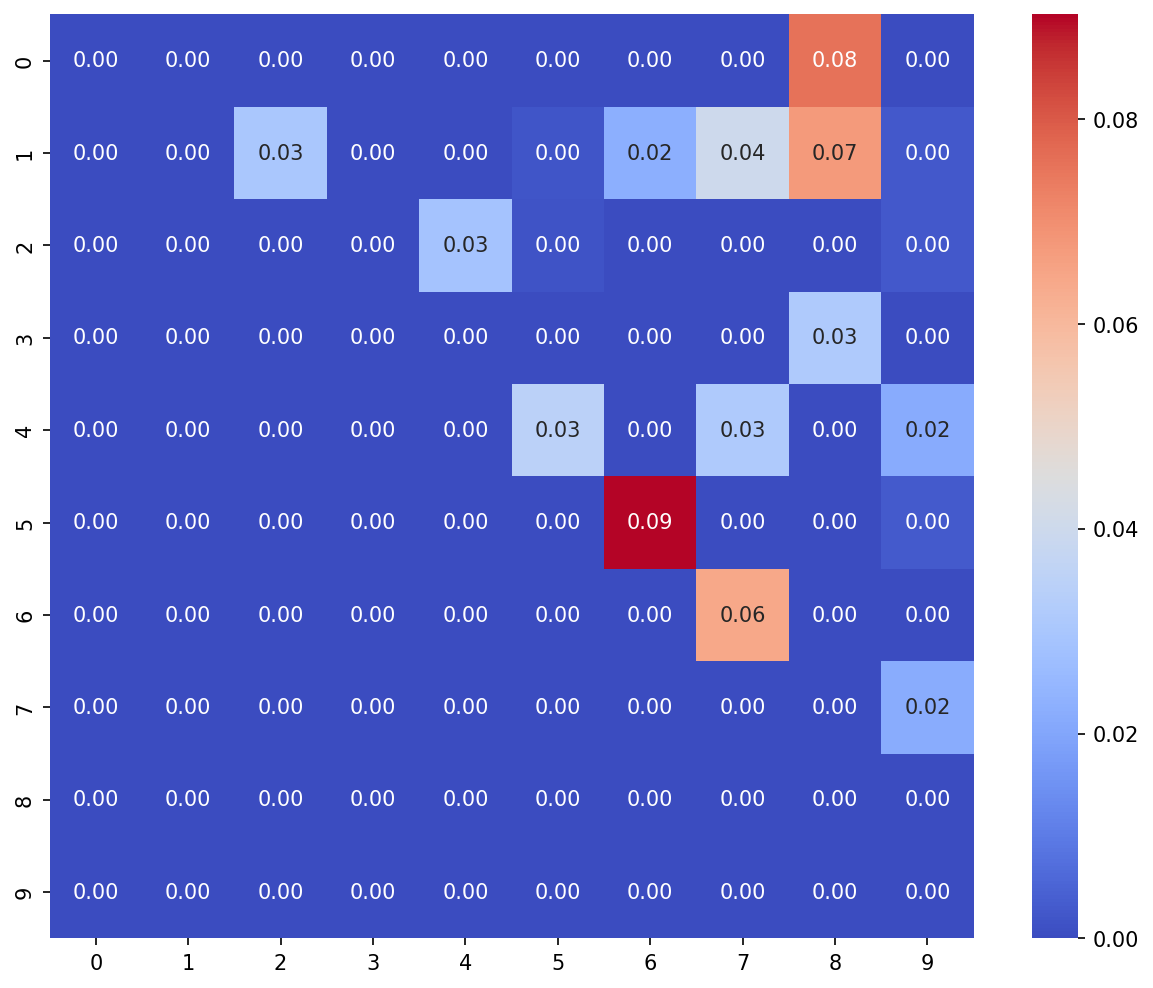

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Select first 10 documents only to show similarity
similarity_matrix = np.zeros((10, 10))

for row in range(10):
    # Only compute upper triangle
    for col in range(row, 10):
        if row != col:
            similarity_matrix[row, col] = cosine_similarity(tfidf_matrix[row], tfidf_matrix[col])
        else:
            similarity_matrix[row, col] = 0

plt.figure(figsize=(10, 8), dpi=150)
sns.heatmap(data=similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.show()

## **Hierarchical Clustering of Document Similarities**


#### **Single Link**


Clusters: [12 20 29 25  1 17 18 21 14  8 30 15 16  3 28  9 10 23  6 26 24  2 11 13
  4 19  7 22 27  5]


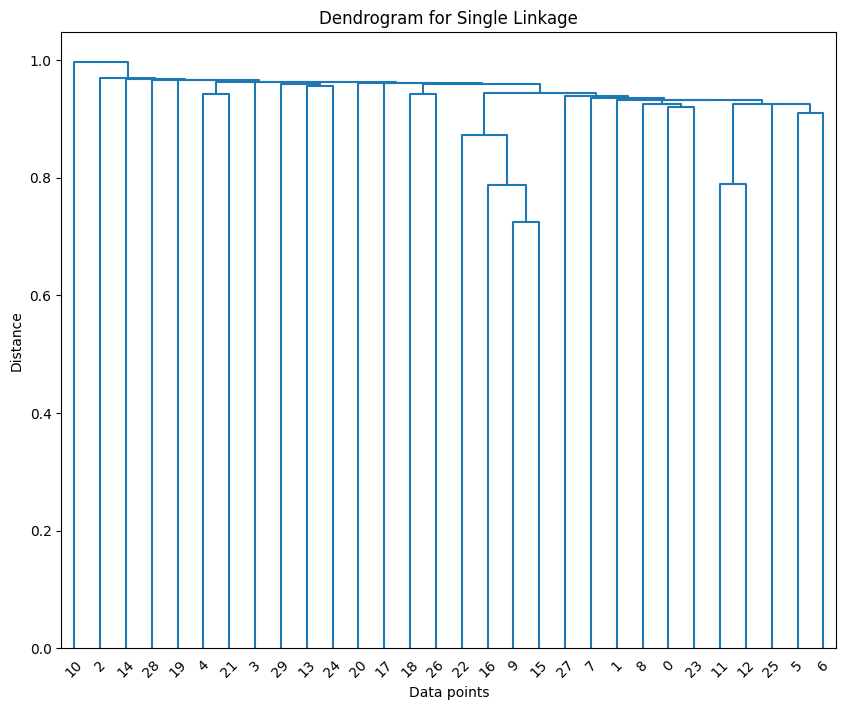

array([[ 9.        , 15.        ,  0.72519719,  2.        ],
       [16.        , 30.        ,  0.78750636,  3.        ],
       [11.        , 12.        ,  0.78944227,  2.        ],
       [22.        , 31.        ,  0.87208808,  4.        ],
       [ 5.        ,  6.        ,  0.90976432,  2.        ],
       [ 0.        , 23.        ,  0.92032984,  2.        ],
       [25.        , 34.        ,  0.92449283,  3.        ],
       [ 8.        , 35.        ,  0.92449554,  3.        ],
       [32.        , 36.        ,  0.92583337,  5.        ],
       [37.        , 38.        ,  0.93219165,  8.        ],
       [ 1.        , 39.        ,  0.9325505 ,  9.        ],
       [ 7.        , 40.        ,  0.93568596, 10.        ],
       [27.        , 41.        ,  0.93946345, 11.        ],
       [ 4.        , 21.        ,  0.94184645,  2.        ],
       [18.        , 26.        ,  0.9427797 ,  2.        ],
       [33.        , 42.        ,  0.94383831, 15.        ],
       [13.        , 24.

In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import fcluster

def single_linkage(tfidf_matrix: dict[int, pd.Series]) -> list:
    """Perform single-linkage hierarchical clustering."""
    # Convert the TF-IDF matrix to a DataFrame so that all the vectors have same dimension
    df = pd.DataFrame(tfidf_matrix).fillna(0).transpose()
    # Perform hierarchical clustering
    linked = linkage(df, method='single', metric="cosine")
    # For logging flattened clusters with a distance threshold
    clusters = fcluster(linked, t=0.5, criterion='distance')
    logger.info(f"Clusters: {clusters}")

    plt.figure(figsize=(10, 8), dpi=100)
    dendrogram(linked, truncate_mode="level")

    plt.title("Dendrogram for Single Linkage")
    plt.xlabel("Data points")
    plt.ylabel("Distance")

    plt.show()

    return linked

single_linkage(tfidf_matrix)

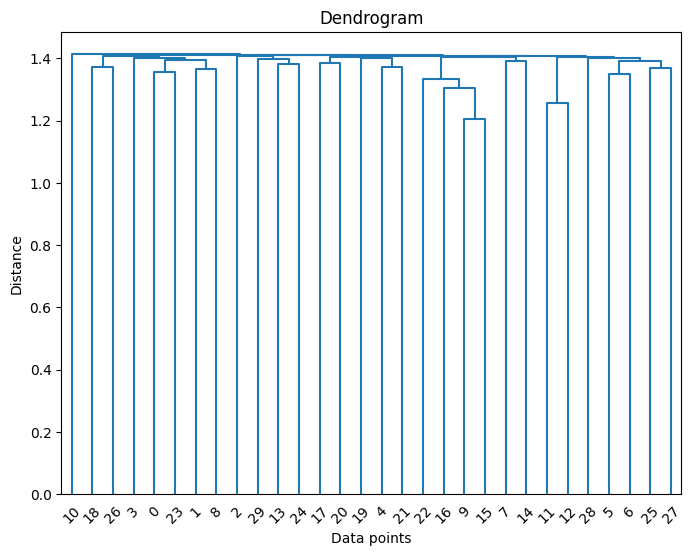

In [31]:
#importing libraries
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt


# Generate sample data (This will create a dataset with two clusters moon's like)
X = pd.DataFrame(tfidf_matrix).transpose().fillna(0)


# Importing library for drawing Dendrogram 
from scipy.cluster.hierarchy import dendrogram, linkage


# Compute linkage matrix
Z = linkage(X, 'average')


# Plot dendrogram
plt.figure(figsize=(8, 6))
dendrogram(Z, truncate_mode='level')
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Distance')
plt.show()

In [30]:
print(Z)

[[ 9.         15.          1.2043232   2.        ]
 [11.         12.          1.25653672  2.        ]
 [16.         22.          1.33899309  2.        ]
 [ 5.          6.          1.34889905  2.        ]
 [ 0.         23.          1.35670914  2.        ]
 [30.         32.          1.35722486  4.        ]
 [ 1.          8.          1.365687    2.        ]
 [25.         27.          1.37073954  2.        ]
 [ 4.         21.          1.37247692  2.        ]
 [18.         26.          1.37315673  2.        ]
 [13.         24.          1.3819769   2.        ]
 [17.         20.          1.38684029  2.        ]
 [ 7.         14.          1.39263756  2.        ]
 [19.         33.          1.39777404  3.        ]
 [31.         37.          1.41247201  4.        ]
 [28.         35.          1.41268236  5.        ]
 [10.         44.          1.41291478  5.        ]
 [ 2.         46.          1.41307429  6.        ]
 [ 3.         36.          1.41421356  3.        ]
 [43.         48.          1.41

In [17]:
def flatten(nested_list):
    flat = []
    for item in nested_list:
        if isinstance(item, list):
            flat.extend(flatten(item))
        else:
            flat.append(item)
    return flat

class HierarchialClustering:
    def _similarity_matrix(self, tfidf_matrix: dict[int | tuple, pd.Series]) -> np.ndarray:
        # Compute the cosine similarity matrix
        similarity_matrix = np.zeros((len(tfidf_matrix), len(tfidf_matrix)))
        for i in range(len(tfidf_matrix)):
            # Only compute upper triangle
            for j in range(i, len(tfidf_matrix)):
                # When i == j the similarity score is one but it is made 0 deliberately to make calculations easy
                if i != j:
                    similarity_matrix[i, j] = cosine_similarity(tfidf_matrix[i], tfidf_matrix[j])
        return similarity_matrix

    def _single_linkage_similarity_matrix(
        self,
        tfidf_matrix: dict[int, pd.Series],
        clusters: list[list[int]],
    ) -> np.ndarray:
        # Compute the single linkage similarity matrix
        # print("Clusters in similarity function:", clusters)
        similarity_matrix = np.zeros((len(clusters), len(clusters)))
        for i in range(len(clusters)):
            for j in range(i, len(clusters)):
                if i != j:
                    # For single linkage the similarity is calculated as the
                    # minimum distance between the closest cluster members
                    similarity_matrix[i, j] = np.max(
                        [
                            cosine_similarity(tfidf_matrix[doc_i], tfidf_matrix[doc_j])
                            for doc_i in flatten(clusters[i])
                            for doc_j in flatten(clusters[j])
                        ],
                    )
                    similarity_matrix[j, i] = similarity_matrix[i, j]
        return similarity_matrix

    def single_linkage(self, tfidf_matrix: dict[int, pd.Series]):
        # Perform single linkage clustering
        # Each cluster will have only that document at the start
        clusters = [[document] for document in tfidf_matrix]
        print("Starting single_linkage with", len(clusters), "clusters")
        length_of_clusters = len(clusters)
        while True:
            # print(clusters)
            # Compute the distance matrix
            similarity_matrix = self._single_linkage_similarity_matrix(tfidf_matrix, clusters)
            # print("Shape of similarity matrix:", similarity_matrix.shape)
            if np.all(similarity_matrix == 0):
                return clusters

            # Find the pair of clusters with the minimum distance
            i, j = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)

            # Combine the two clusters with the minimum distance
            # cluster_i = clusters[i]
            # cluster_j = clusters[j]
            # print(f"Combining clusters {i} and {j} with documents {cluster_i} and {cluster_j}")
            # new_cluster = [*clusters[i], *clusters[j]]
            # print("New cluster:", new_cluster)
            # Remove these two clusters

            if i != j:
                new_cluster = []
                for idx in sorted([i, j], reverse=True):
                    new_cluster.append(clusters.pop(idx))
                clusters = [*clusters, new_cluster]
            length_of_clusters = len(clusters)
            if length_of_clusters == 1:
                return clusters
            
    def single_link(self, X: list[list[float]], K: int) -> list[int]:
        """
        Single link hierarchical clustering
        Args:
          - X: 2D input data
          - K: the number of output clusters
        Returns:
          A list of integers (range from 0 to K - 1) that represent class labels.
          The number does not matter as long as the clusters are correct.
          For example: [0, 0, 1] is treated the same as [1, 1, 0]
        """
        # implement this function
        clusters = [[i] for i in range(len(X))]

        while len(clusters) > K:
            min_dist = float('inf')
            merge = (-1, -1)
            for i in range(len(clusters)):
                for j in range(i + 1, len(clusters)):
                    dist = min(cosine_similarity(X[p], X[q]) for p in clusters[i] for q in clusters[j])
                    # If distance is smaller than minimum distance then merge it to same cluster
                    if dist < min_dist:
                        min_dist = dist
                        merge = (i, j)

            i, j = merge
            clusters[i].extend(clusters[j])
            clusters.pop(j)

        labels = [0] * len(X)
        for cluster_id, cluster in enumerate(clusters):
            for idx in cluster:
                labels[idx] = cluster_id

        return labels

In [18]:
# from pprint import pprint
import json
hac = HierarchialClustering()
def print_dendrogram(nested, indent=0):
    """Recursively print a text-based dendrogram with arrows."""
    prefix = " " * indent
    if isinstance(nested, list) and len(nested) == 1:
        print(f"{prefix}→ {nested[0]}")
    elif isinstance(nested, list):
        print(f"{prefix}└─")
        for child in nested:
            print_dendrogram(child, indent + 2)
    else:
        print(f"{prefix}→ {nested}")

        
print_dendrogram(hac.single_linkage(tfidf_matrix=tfidf_matrix)[0], indent=2)

Starting single_linkage with 30 clusters
  └─
    └─
      └─
        └─
          └─
            └─
              └─
                └─
                  └─
                    └─
                      └─
                        └─
                          └─
                            └─
                              └─
                                └─
                                  └─
                                    └─
                                      └─
                                        → 6
                                        → 5
                                      → 25
                                    └─
                                      → 12
                                      → 11
                                  └─
                                    └─
                                      → 23
                                      → 0
                                    → 8
                                → 1
                             

Starting single_linkage with 30 clusters
Starting single_linkage with 30 clusters
Starting single_linkage with 30 clusters


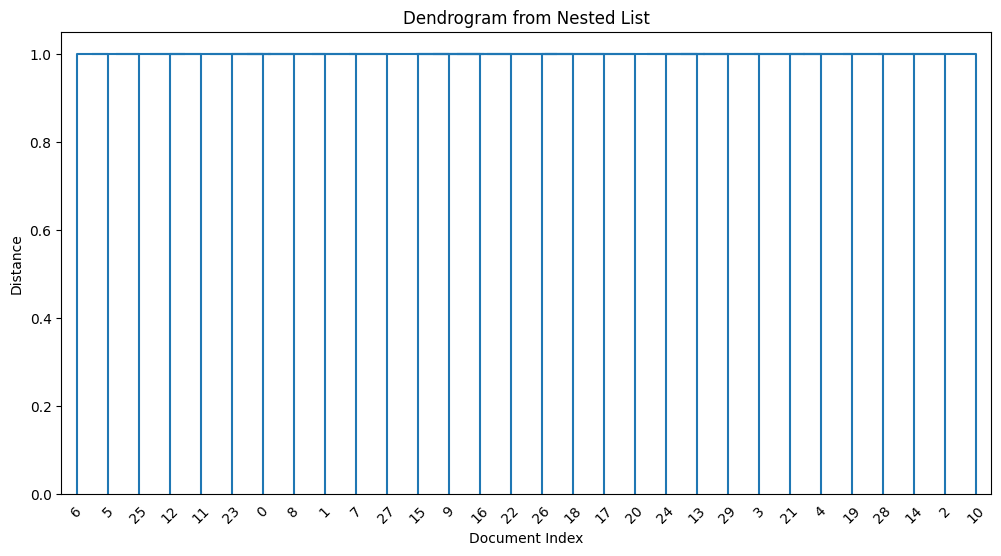

In [19]:
from scipy.cluster.hierarchy import dendrogram
def build_linkage(nested, next_cluster_id, linkage, cluster_ids):
    """Recursively build the linkage matrix from a nested list."""
    if not isinstance(nested, list) or len(nested) == 1 and not isinstance(nested[0], list):
        # Leaf node
        leaf = flatten(nested)
        return cluster_ids[leaf[0]]
    elif len(nested) == 2:
        left = build_linkage(nested[0], next_cluster_id, linkage, cluster_ids)
        right = build_linkage(nested[1], next_cluster_id, linkage, cluster_ids)
        n_leaves = len(flatten(nested))
        # Use a dummy distance (e.g., step number or 1.0)
        linkage.append([left, right, 1.0, n_leaves])
        cluster_id = next_cluster_id[0]
        next_cluster_id[0] += 1
        return cluster_id
    else:
        # For more than two children, merge sequentially
        current = build_linkage(nested[0], next_cluster_id, linkage, cluster_ids)
        for child in nested[1:]:
            next_child = build_linkage(child, next_cluster_id, linkage, cluster_ids)
            n_leaves = len(flatten([nested[0], child]))
            linkage.append([current, next_child, 1.0, n_leaves])
            current = next_cluster_id[0]
            next_cluster_id[0] += 1
        return current
def nested_list_to_linkage(nested):
    leaves = sorted(flatten(nested))
    cluster_ids = {leaf: idx for idx, leaf in enumerate(leaves)}
    linkage = []
    next_cluster_id = [len(leaves)]
    build_linkage(nested, next_cluster_id, linkage, cluster_ids)
    return np.array(linkage)

linkage_matrix = nested_list_to_linkage(hac.single_linkage(tfidf_matrix=tfidf_matrix))
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=[str(i) for i in sorted(flatten(hac.single_linkage(tfidf_matrix=tfidf_matrix)))])
plt.title("Dendrogram from Nested List")
plt.xlabel("Document Index")
plt.ylabel("Distance")
plt.show()